In [1]:
import os

# Currently only OpenAI models are supported.
# https://developers.openai.com/api/docs/models
# In future updates, one would be able to configure other models
os.environ["OPENAI_API_KEY"] = ""


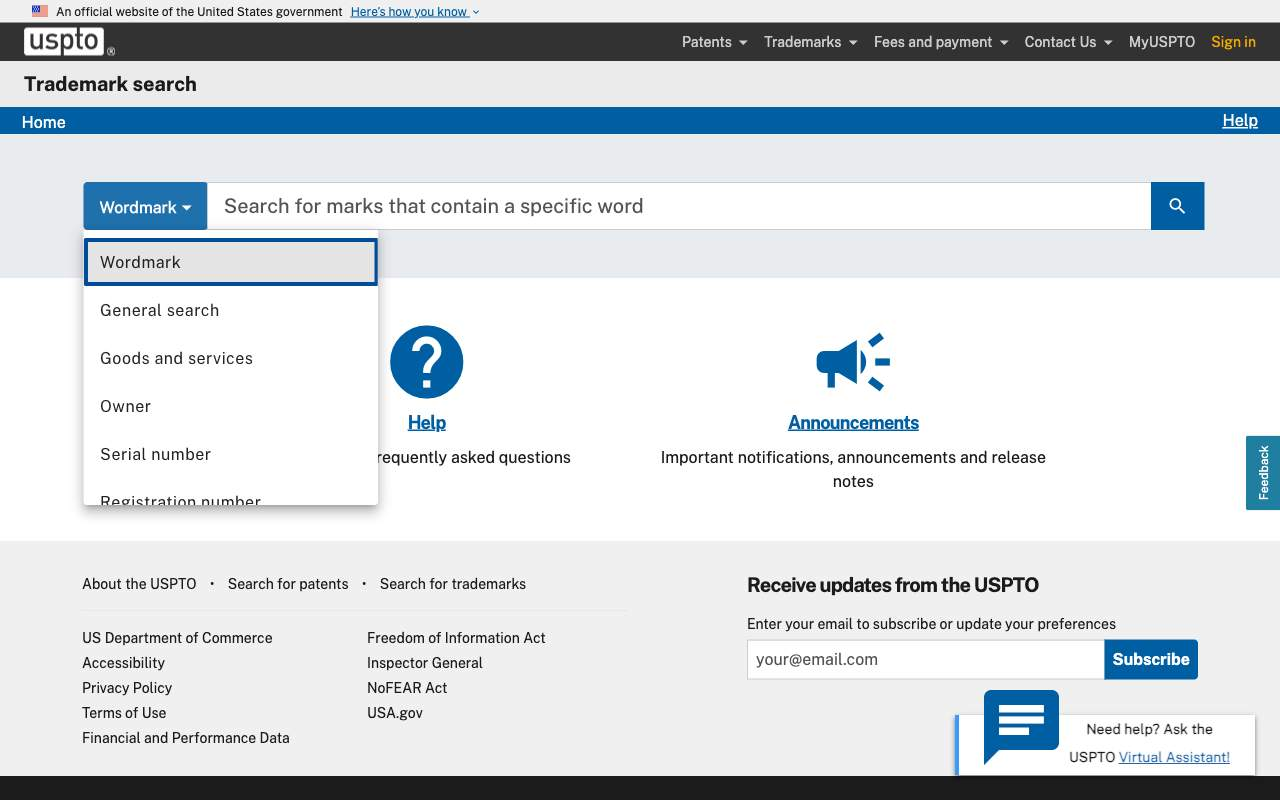

In [4]:
# To keep live navigation in context

import asyncio
import base64
import os
from IPython.display import HTML, display

from lexoid.api import browse
from lexoid.core.browse.schemas import BrowserActionTrace
from lexoid.core.browse.session import GhostBrowserSession
from lexoid.core.ghost import _get_async_playwright

BROWSER_FRAME_HTML = """
<div style="border: 2px solid #333; border-radius: 6px; width: 100%; max-width: 960px; overflow: hidden; font-family: monospace; background: #222;">
    <div style="background: #111; padding: 8px; display: flex; align-items: center; border-bottom: 2px solid #333;">
        <span style="height: 10px; width: 10px; background: #ff5f56; border-radius: 50%; display: inline-block; margin-right: 5px;"></span>
        <span style="height: 10px; width: 10px; background: #ffbd2e; border-radius: 50%; display: inline-block; margin-right: 5px;"></span>
        <span style="height: 10px; width: 10px; background: #27c93f; border-radius: 50%; display: inline-block; margin-right: 15px;"></span>
        <input id="cell-url-display" type="text" value="{url}" style="width: 85%; padding: 4px; border: none; background: #333; color: #fff; border-radius: 3px; font-size: 11px;" readonly />
    </div>
    <div style="display: flex; justify-content: center; align-items: center; min-height: 550px; background: #fff;">
        <img id="live-cell-viewport" src="{src}" style="width: 100%; height: auto; display: block;" />
    </div>
</div>
"""


class NotebookInteractiveViewer:

    def __init__(self, fps: float = 4.0):
        self.frame_interval = 1.0 / fps
        self.current_session = None
        self.active_tab_id = None
        self.current_url = "Awaiting Agent Launch..."
        self._stream_task = None
        self._display_handle = display(
            HTML(BROWSER_FRAME_HTML.format(url=self.current_url, src="")),
            display_id=True,
        )

    def _push_frame(self, jpeg_bytes: bytes):
        b64_img = base64.b64encode(jpeg_bytes).decode("utf-8")
        html = BROWSER_FRAME_HTML.format(
            url=self.current_url,
            src=f"data:image/jpeg;base64,{b64_img}",
        )
        self._display_handle.update(HTML(html))

    async def _stream_loop(self):
        while True:
            if self.current_session and self.active_tab_id:
                page = self.current_session._owned_pages.get(self.active_tab_id)
                if page and not getattr(page, "is_closed", lambda: False)():
                    try:
                        self.current_url = getattr(
                            page, "url", self.current_url
                        )
                        frame = await page.screenshot(
                            type="jpeg", quality=65, scale="css"
                        )
                        self._push_frame(frame)
                    except Exception:
                        pass
            await asyncio.sleep(self.frame_interval)

    async def on_event(self, trace: BrowserActionTrace):
        if trace.tab_id:
            self.active_tab_id = trace.tab_id

        if trace.event == "observation":
            if self._stream_task is None or self._stream_task.done():
                self._stream_task = asyncio.create_task(self._stream_loop())
        elif trace.event == "action" and trace.result:
            if trace.result.opened_tab_id:
                self.active_tab_id = trace.result.opened_tab_id
            if trace.result.after_url:
                self.current_url = trace.result.after_url
        elif trace.event == "terminal":
            if self._stream_task:
                self._stream_task.cancel()
                try:
                    await self._stream_task
                except asyncio.CancelledError:
                    pass
                self._stream_task = None


viewer = NotebookInteractiveViewer(fps=4.0)

# Unwind previous wraps to prevent recursion
if hasattr(GhostBrowserSession, "_unwrapped_aenter"):
    GhostBrowserSession.__aenter__ = GhostBrowserSession._unwrapped_aenter
else:
    GhostBrowserSession._unwrapped_aenter = GhostBrowserSession.__aenter__


async def _notebook_session_aenter(self):
    viewer.current_session = self
    factory, _ = _get_async_playwright(self._config)
    self._playwright = await factory().start()

    if self._config.cdp_url:
        self._browser = await self._playwright.chromium.connect_over_cdp(
            self._config.cdp_url
        )
        self._context = self._browser.contexts[0]
    else:
        # Crucial flags: Keep Chrome rendering offscreen without throttling or triggering WindowServer minimize flickers
        launch_args = [
            "--disable-blink-features=AutomationControlled",
            "--disable-infobars",
            "--no-sandbox",
            "--window-size=1280,800",
            # "--window-position=-3000,-3000",  # Positions it completely off-screen cleanly
        ]
        launch_kwargs = {
            "headless": False,  # Always keep False under the hood for stealth
            "args": launch_args,
            "channel": "chrome",
        }
        try:
            self._browser = await self._playwright.chromium.launch(
                **launch_kwargs
            )
        except Exception:
            # Fallback if standard Chrome isn't registered
            launch_kwargs.pop("channel", None)
            self._browser = await self._playwright.chromium.launch(
                **launch_kwargs
            )

        self._context = await self._browser.new_context(
            viewport={"width": 1280, "height": 800}
        )

    return self


GhostBrowserSession.__aenter__ = _notebook_session_aenter

In [ ]:
from lexoid.api import browse

# Sample examples:
# - Go to https://tmsearch.uspto.gov/ and retrieve all cases for Arash Samadani as attorney, filter only live cases.
# - Access EOIR, https://acis.eoir.justice.gov, and get latest update on alien number: 123-456-789, country of origin - Mexico. Is there a new deadline?",

# - Navigate to the Facebook Ad Library, https://www.facebook.com/ads/library. 
    # Search for all active ads currently running in the United States by the page 'Morgan & Morgan'. 
    # Scroll to load the 10 most recent active ads. Extract the primary headline copy, the call-to-action (CTA) text, and flag whether the ad is using a video or an image. 
    # Output as a structured Markdown table.

# - # Use https://www.loopnet.com/search/commercial-real-estate/irvine-ca/for-lease/ and shortlist 3 properties likely suited for opening a Korean BBQ restaurant.
    # Additional criteria:
    # - 'Minimum Size'>='5,000 SF'
    # Give me street addresses (sorted by price low to high).

# - # I’m trying to decide whether driving this week is a bad idea, 
    # so can you build me a quick weather risk snapshot that starts with what it feels like right now and then widens out to the bigger trouble spots? 
    # First, on Google (https://www.google.com/), search for Baltimore, Maryland weather and grab the current temperature plus the plain-English condition like cloudy, sunny, rain, or whatever it says, 
    # just so I have a baseline for home conditions. 
    # Then go to Wunderground (https://www.wunderground.com/) and look up Syracuse, New York, and check the 10-day/7-day style forecast to find the lowest temperature expected over the next 7 days, including which day it happens, because I want to compare that colder destination against Baltimore. After that, use the National Weather Service forecast page for the Rittman, Ohio area near Marshallville and tell me what the current forecast says and whether there are any active alerts posted there, since that would really affect an Ohio leg of the drive; please open the actual forecast page and leave it visible so I can see the alert area and forecast text myself. 
    # Finally, go to the NWS Mount Holly page, find the winter forecast graphic, and report the snowfall amount shown there so I can tell whether the Mid-Atlantic part looks like a nuisance event or something more serious; if the graphic opens separately, leave that tab open too so I can look at the map. In the end, send me a short location-by-location summary with the key weather risk for Baltimore, Syracuse, Rittman/Marshallville, and the Mount Holly region.
    # """,

query = """
Go to https://tmsearch.uspto.gov/ and retrieve all cases for Arash Samadani as attorney, filter live cases.
"""

# Default setting for all agent config
_mc_1 = {"default": {"model": "gpt-5.6-sol", "reasoning": {"effort": "medium"}}}

# Detailed config
_mc_2 = {
    "planner": {
        "model": "gpt-5.6-sol",
        "reasoning": {"effort": "medium", "summary": "detailed"},
        "options": {"verbosity": "high"},
    },
    "navigator": {
        "model": "gpt-5.6-sol",
        "reasoning": {"effort": "medium"},
    },
    "extractor": {
        "model": "gpt-6-luna",
        "reasoning": {"effort": "high"}
    },
    "synthesizer": {
        "model": "gpt-6-luna",
        "reasoning": {"effort": "medium"}
    }
}
result = await browse(
   query,
    model_config=_mc_2,
    headless=False,
    event_listener=viewer.on_event, # enable to keep navigation contextual
)

In [13]:
print(result.answer)

The USPTO search for **Arash Samadani** as attorney of record, filtered to live results, returned **44 cases** on one page. All 44 listed results are marked **Live Registered**.

| Serial number | Mark | Status |
|---|---|---|
| 88624226 | 12 DRUMMERS DRUMMING | Live Registered |
| 88624233 | DEMOCRATIZING DERMATOLOGY | Live Registered |
| 88778758 | BRITE IDEAS | Live Registered |
| 90173369 | JUST A KISS | Live Registered |
| 90173381 | JUST A TWIST | Live Registered |
| 90603424 | DREAM ON | Live Registered |
| 85632994 | MISCHIEF | Live Registered |
| 87341142 | MRS. SMITH | Live Registered |
| 86117192 | THE BRUERY | Live Registered |
| 88402791 | ALOHA FRIDAY | Live Registered |
| 99021495 | FIRST CLASS CONNECTION | Live Registered |
| 88164661 | WIT THE FUNK | Live Registered |
| 86115957 | HOARDERS SOCIETY | Live Registered |
| 85657056 | 2 TURTLE DOVES | Live Registered |
| 85657105 | 4 CALLING BIRDS | Live Registered |
| 86179202 | RUGBRØD | Live Registered |
| 86189753 | SOU